# Intraday MXF signals — time-of-day forward-filled features

Different angle from `intraday_signals.ipynb`: instead of computing a signal every bar, **lock a feature once at a specific time of day, then forward-fill it as a held position until session close** (or to the next reset). One trade in, one trade out — turnover ~2 / day instead of ~2 / bar. Costs collapse, so any edge has a fair chance of surviving.

Canonical example: the *first 5-min day-open return* (close@08:50 ÷ open@08:46 − 1). Place that scalar at 08:50, ffill until 13:45, hold. The hypothesis: an opening drive carries the rest of the session (continuation) — or fades (reversal). Test both signs.

## Features tested
1. **Open 5-min return** (open@08:46 → close@08:50) ffilled to 13:45
2. **Open 30-min return** (open@08:46 → close@09:15) ffilled to 13:45
3. **Overnight gap** (prev day close@13:46 → today open@08:46) ffilled across day session
4. **Open 30-min range** (high-low / close, 08:46-09:15) — *signed* by the open return (vol-scaled directional bet)
5. **Open 5-min volume z-score** vs trailing 20-day mean/std of the same window — abnormal-attention signal
6. **Close 30-min return** (close@13:15 → close@13:45) — carried to *next* day's session (smart-money close persists?)

Each is normalized to roughly ±1 by `tanh(x / σ)` using its own trailing stdev, then both signs are simulated.

**In-sample**: 2023-03-13 → 2024-12-31.

In [1]:
import importlib, sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = [
    "Hiragino Sans GB", "Heiti TC", "Songti SC",
    "PingFang HK", "Arial Unicode MS", "DejaVu Sans",
]

import cta
for _m in ["cta.asset","cta.operators","cta.simulate",
           "cta.simulate_intraday","cta.session_strategies"]:
    if _m in sys.modules: importlib.reload(sys.modules[_m])
importlib.reload(cta)

IN_SAMPLE_START = "2023-03-13"
IN_SAMPLE_END   = "2026-12-31"
cta.set_date_range(start_date=IN_SAMPLE_START, end_date=IN_SAMPLE_END)

ASSET = cta.load_asset("mtx", "1m")
cta.set_active_asset(ASSET)

print(f"asset       : {ASSET.symbol}  {ASSET.time_granularity}  {len(ASSET):,} bars")
print(f"window      : {ASSET.index[0]} → {ASSET.index[-1]}")
print(f"eval window : {cta.get_date_range()}")

asset       : MTX  1m  880,850 bars
window      : 2023-03-13 08:46:00 → 2026-05-22 13:45:00
eval window : (Timestamp('2023-03-13 00:00:00'), Timestamp('2026-12-31 00:00:00'))


## Helpers — evaluator + the forward-fill builder

The evaluator mirrors `cta.SimulateIntraday`'s internal maths so the summary numbers match the 9-panel dashboard.

`build_tod_signal(feature_by_date, emit_time, hold_until)` is the workhorse: it takes a per-date scalar, places it at `emit_time` on each date, forward-fills to `hold_until`, and zeroes elsewhere. The resulting series is what gets fed into `cta.SimulateIntraday` exactly like any other signal.

In [2]:
POINT_VALUE    = 50.0
FIXED_PER_SIDE = 20.0
FEE_RATE       = 0.00002

def evaluate(sig, asset=ASSET, start=IN_SAMPLE_START, end=IN_SAMPLE_END):
    sig = sig.reindex(asset.index).astype(float)
    exec_sig = sig.shift(2)
    ret      = asset.returns
    pnl      = (exec_sig * ret).rename("pnl")
    turnover = exec_sig.fillna(0).diff().abs()
    cost_pct = FIXED_PER_SIDE / (asset.close * POINT_VALUE) + FEE_RATE
    tcost    = turnover * cost_pct
    pnl_net  = pnl - tcost
    pnl, pnl_net = pnl.loc[start:end], pnl_net.loc[start:end]
    exec_s = exec_sig.loc[start:end]
    sess   = asset.session.loc[start:end]
    periods = asset.periods_per_year
    def sr(s):
        s = s.dropna()
        return (np.sqrt(periods) * s.mean() / s.std()) if s.std() > 0 else float("nan")
    return {
        "SR_gross": sr(pnl),
        "SR_net":   sr(pnl_net),
        "SR_day":   sr(pnl.where(sess == "day")),
        "SR_night": sr(pnl.where(sess == "night")),
        "cum_gross_pct": float(pnl.fillna(0).sum())     * 100,
        "cum_net_pct":   float(pnl_net.fillna(0).sum()) * 100,
        "held_pct":      float((exec_s.abs() > 0.01).mean()) * 100,
        "turnover_avg":  float(turnover.loc[start:end].fillna(0).mean()),
    }

def summarize(rows):
    df = pd.DataFrame({n: evaluate(s) for n, s in rows.items()}).T
    return df.round(3).sort_values("SR_net", ascending=False)

def build_tod_signal(feature_by_date: pd.Series,
                     emit_time: str,
                     hold_until: str,
                     asset=ASSET) -> pd.Series:
    """Place a per-date scalar at `emit_time` each day; ffill to `hold_until`; 0 elsewhere.

    feature_by_date : pd.Series indexed by date (pd.Timestamp at 00:00 or .date()).
    emit_time       : 'HH:MM' — when the value first becomes known.
    hold_until      : 'HH:MM' — last bar to keep the value (exclusive of next day).
    """
    idx = asset.index
    emit_t = pd.Timestamp(emit_time).time()
    end_t  = pd.Timestamp(hold_until).time()
    in_window = (idx.time >= emit_t) & (idx.time <= end_t)

    fbd = pd.Series(feature_by_date)
    fbd.index = pd.to_datetime(fbd.index).normalize()

    sig = pd.Series(np.nan, index=idx)
    at_emit = idx.time == emit_t
    emit_dates = pd.to_datetime(pd.Series(idx[at_emit]).dt.normalize())
    sig.loc[at_emit] = emit_dates.map(fbd).values

    dates = pd.Series(idx.normalize(), index=idx)
    sig = sig.groupby(dates.values).ffill()
    sig[~in_window] = 0.0
    return sig.rename("tod_sig")

def tanh_norm(s, win=60):
    """Tanh-normalize a daily feature by trailing-`win`-day stdev."""
    s = s.dropna().astype(float)
    sd = s.rolling(win, min_periods=10).std().shift(1)
    return np.tanh(s / sd).rename(s.name)

# Convenience: per-date series keyed by date.normalize()
def at_time(series, hhmm):
    s = series.copy()
    s = s[s.index.time == pd.Timestamp(hhmm).time()]
    s.index = s.index.normalize()
    return s

C = ASSET.close
O = ASSET.open
H = ASSET.high
L = ASSET.low
V = ASSET.volume

print("helpers ready.")

helpers ready.


## 1a. Intraday return seasonality — CAAR from market open

Before deciding how long to hold a forward-filled signal, look at where in the day the *average* return is actually realized. Use `cta.Caar` on 1-min returns with event dates = each day's 08:46 open bar, window = 300 bars (5h = full day session). The right half of the resulting CAAR (relative bar 0 → +300) is the average cumulative path from market open through close.

If the curve is monotone up/down, holding to 13:45 is fine; if it tops out at lunch, an earlier exit captures the same gain with less cost and less risk.

open events: 774 days


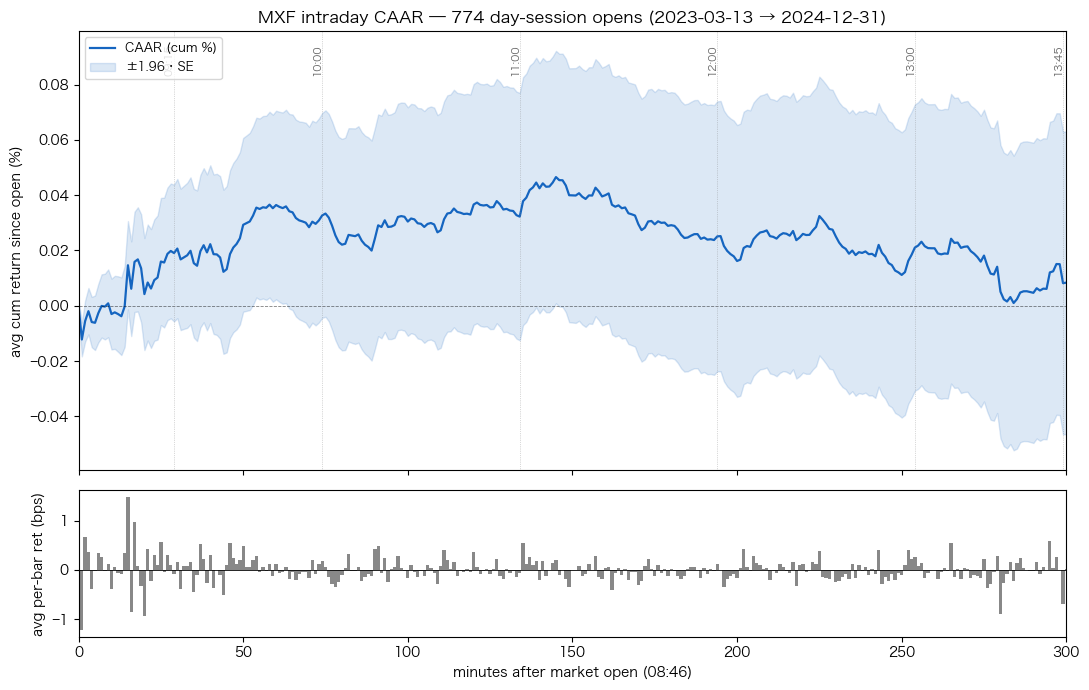


Cum return since open (avg %), at common hold-until times:
  09:15  (bar + 29)  +0.019%
  10:00  (bar + 74)  +0.033%
  11:00  (bar +134)  +0.032%
  12:00  (bar +194)  +0.025%
  13:00  (bar +254)  +0.021%
  13:45  (bar +299)  +0.008%


In [12]:
# Build 1-min returns and 08:46 opening-bar events
ret_1m = ASSET.returns                                  # rollover-aware 1m returns
open_bars = ASSET.index[ASSET.index.time == pd.Timestamp("08:46").time()]
print(f"open events: {len(open_bars)} days")

WINDOW = 300       # 300 bars = 5h, full day session length
caar = cta.Caar(WINDOW, ret_1m, event_dates=open_bars)
# Only the open→close half is meaningful (left half is pre-open night session)
intraday = caar.loc[0:WINDOW].copy()
# Anchor casr to 0 at the open bar so we read it as "% gained since open"
intraday["casr"] = intraday["casr"] - intraday["casr"].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(intraday.index, intraday["casr"] * 100, color="#1565c0", lw=1.6,
         label="CAAR (cum %)")
band = 1.96 * np.sqrt(np.cumsum(intraday["se"].values**2)) * 100
ax1.fill_between(intraday.index, intraday["casr"]*100 - band,
                 intraday["casr"]*100 + band, color="#1565c0", alpha=0.15,
                 label="±1.96·SE")
ax1.axhline(0, color="black", lw=0.6, ls="--", alpha=0.5)
ax1.set_ylabel("avg cum return since open (%)")
ax1.set_title(f"MXF intraday CAAR — {len(open_bars)} day-session opens "
              f"({IN_SAMPLE_START} → {IN_SAMPLE_END})")
ax1.legend(loc="upper left", fontsize=9)

ax2.bar(intraday.index, intraday["mean"] * 1e4, color="#888", width=1.0)
ax2.axhline(0, color="black", lw=0.6)
ax2.set_xlabel("minutes after market open (08:46)")
ax2.set_ylabel("avg per-bar ret (bps)")
ax2.set_xlim(0, WINDOW)

# Mark common ffill horizons
for label, mins in [("09:15", 29), ("10:00", 74), ("11:00", 134),
                    ("12:00", 194), ("13:00", 254), ("13:45", 299)]:
    ax1.axvline(mins, color="grey", lw=0.5, ls=":", alpha=0.6)
    ax1.text(mins, ax1.get_ylim()[1]*0.95, label, fontsize=8,
             rotation=90, va="top", ha="right", alpha=0.6)

plt.tight_layout(); plt.show()

# Print the value at each candidate hold-until time
print("\nCum return since open (avg %), at common hold-until times:")
for label, mins in [("09:15", 29), ("10:00", 74), ("11:00", 134),
                    ("12:00", 194), ("13:00", 254), ("13:45", 299)]:
    if mins in intraday.index:
        print(f"  {label}  (bar +{mins:3d})  {intraday.loc[mins, 'casr']*100:+.3f}%")

## 1. Open 5-min day return — ffilled to 13:45

The simplest test: does the first 5 minutes of the day-session predict the rest of the day?

- Feature: `close@08:50 / open@08:46 − 1`
- Emit at 08:50, hold to 13:45
- Test both signs (`+` continuation, `−` fade)

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
open5_cont,0.11,-0.016,0.087,0.922,2.785,-0.40,25.233,0.001
open5_fade,-0.11,-0.235,-0.087,-0.922,-2.785,-5.97,25.233,0.001


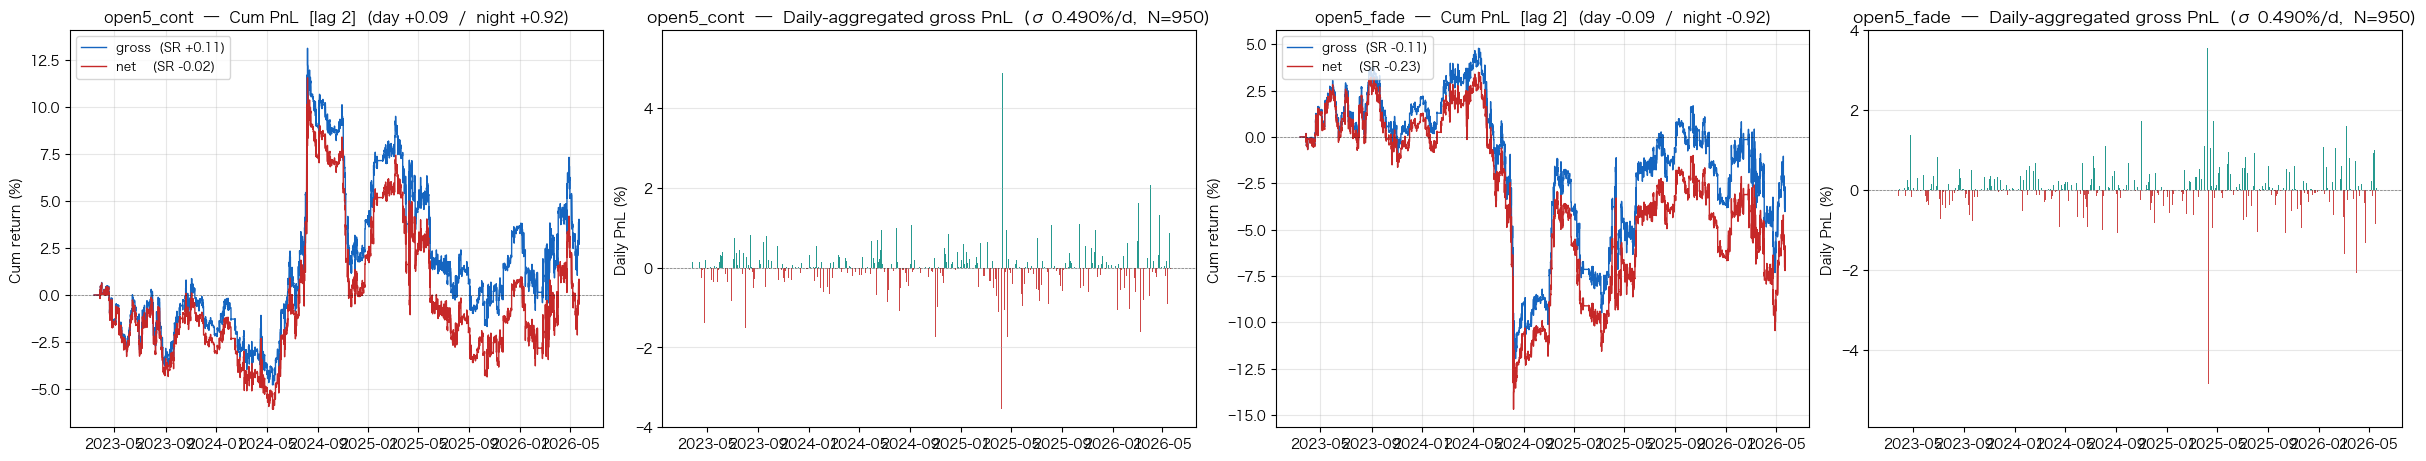

In [3]:
ret_open5 = (at_time(C, "08:50") / at_time(O, "08:46") - 1.0).dropna()
ret_open5_n = tanh_norm(ret_open5, win=60)

open5_signals = {
    "open5_cont":  build_tod_signal( ret_open5_n, "08:50", "13:45"),
    "open5_fade":  build_tod_signal(-ret_open5_n, "08:50", "13:45"),
}
display(summarize(open5_signals))

cta.SimulateAllIntraday(
    *open5_signals.values(),
    names=list(open5_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 1b. Hold-horizon sweep — open5 signal

Instead of forward-filling to 13:45 unconditionally, sweep over shorter horizons. The CAAR above tells us where the average return is concentrated; this confirms whether shorter holds give better *net* SR for the open5 signal specifically (turnover stays low either way; the question is whether late-session bars dilute the edge).

In [ ]:
HOLDS = ["09:15", "10:00", "11:00", "12:00", "13:00", "13:45"]

sweep_signals = {}
for h in HOLDS:
    sweep_signals[f"open5_cont_to_{h.replace(':','')}"] = build_tod_signal( ret_open5_n, "08:50", h)
    sweep_signals[f"open5_fade_to_{h.replace(':','')}"] = build_tod_signal(-ret_open5_n, "08:50", h)

display(summarize(sweep_signals))

cta.SimulateAllIntraday(
    *sweep_signals.values(),
    names=list(sweep_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 2. Open 30-min day return — ffilled to 13:45

Same shape, longer signal window. More information per emission, but also "uses up" the move it's measuring.

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
open30_cont,0.821,0.654,1.379,1.161,9.296,7.402,23.102,0.001
open30_fade,-0.821,-0.988,-1.379,-1.161,-9.296,-11.189,23.102,0.001


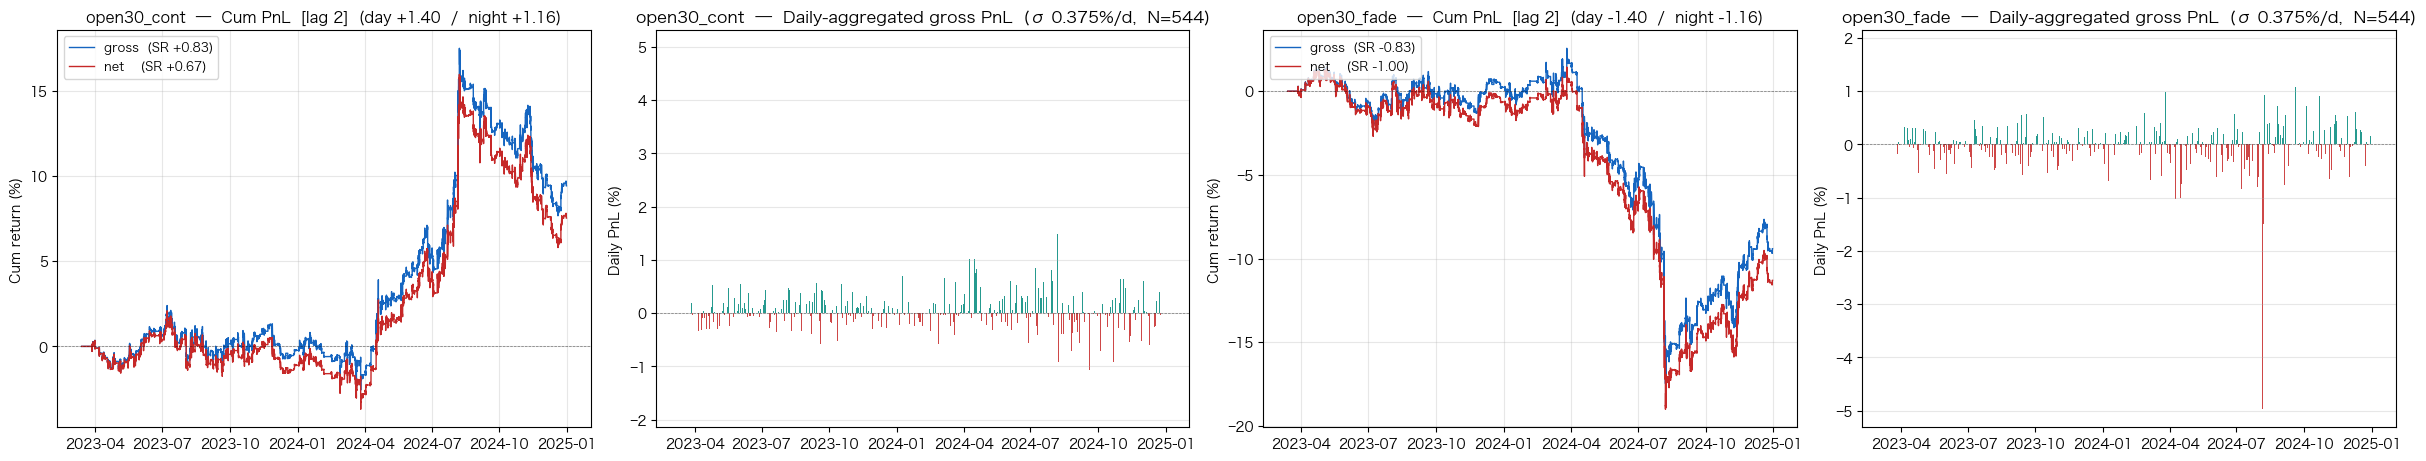

In [4]:
ret_open30 = (at_time(C, "09:15") / at_time(O, "08:46") - 1.0).dropna()
ret_open30_n = tanh_norm(ret_open30, win=60)

open30_signals = {
    "open30_cont":  build_tod_signal( ret_open30_n, "09:15", "13:45"),
    "open30_fade":  build_tod_signal(-ret_open30_n, "09:15", "13:45"),
}
display(summarize(open30_signals))

cta.SimulateAllIntraday(
    *open30_signals.values(),
    names=list(open30_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 3. Overnight gap — prev day close → today day-open

Feature is known *at* 08:46 of the new day (the opening print is the first bar of the day-session). So we emit at 08:46 and hold the whole day. Tests the classic overnight-gap continuation vs gap-fade behaviour.

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
gap_cont,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
gap_fade,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0


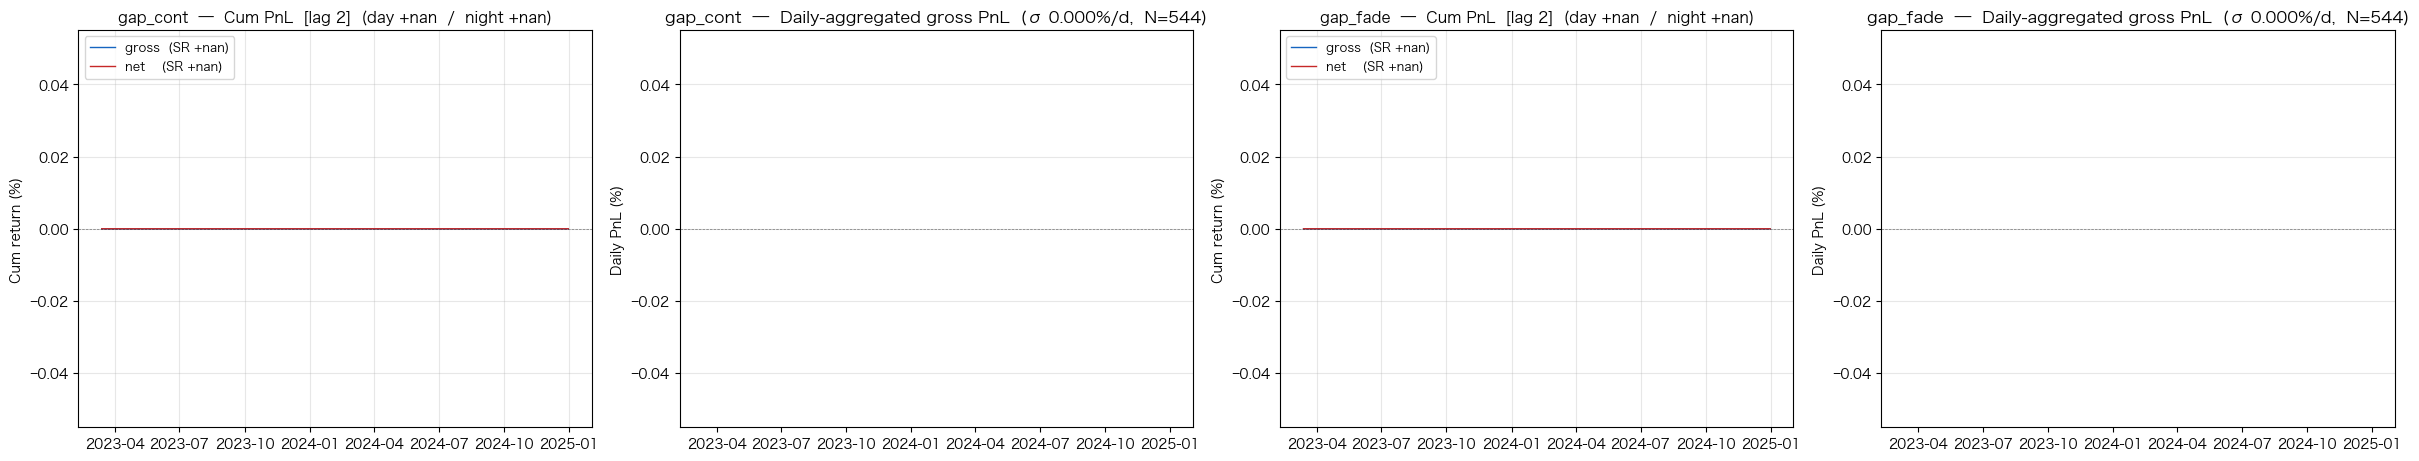

In [5]:
# Prev day's day-close close@13:46 → today's open@08:46
prev_close = at_time(C, "13:46").shift(1)        # "yesterday's close" indexed at today's date
today_open = at_time(O, "08:46")
gap = (today_open / prev_close - 1.0).dropna()
gap_n = tanh_norm(gap, win=60)

gap_signals = {
    "gap_cont":  build_tod_signal( gap_n, "08:46", "13:45"),
    "gap_fade":  build_tod_signal(-gap_n, "08:46", "13:45"),
}
display(summarize(gap_signals))

cta.SimulateAllIntraday(
    *gap_signals.values(),
    names=list(gap_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 4. Open 30-min range, signed by open direction

A wide opening range tends to mean a trending day. Take `(high − low) / close` over the first 30 min, **multiplied by the sign of the 30-min return**, so it's a *directional* bet scaled by realized volatility. The bigger the morning's move, the bigger the daily exposure.

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
rng30_cont,0.807,0.624,1.369,1.199,10.598,8.197,23.102,0.001
rng30_fade,-0.807,-0.990,-1.369,-1.199,-10.598,-12.999,23.102,0.001


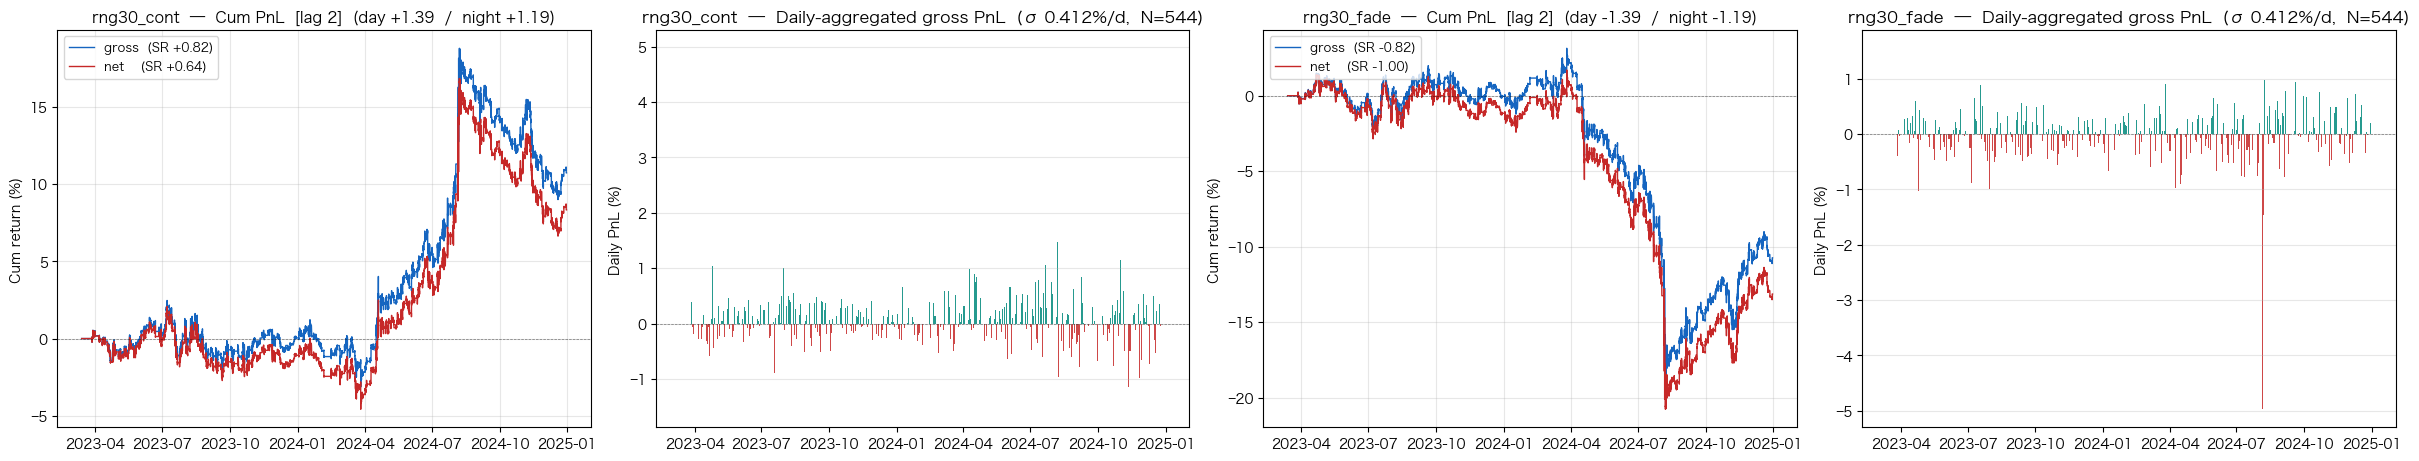

In [6]:
# Aggregate first-30-min H/L per day
first30 = ASSET.between_time("08:46", "09:15")
g = first30.groupby(first30.index.normalize())
rng_open30 = ((g["high"].max() - g["low"].min()) / g["close"].last())
sign_open30 = np.sign(ret_open30).reindex(rng_open30.index)
rng_dir = (rng_open30 * sign_open30).dropna()
rng_dir_n = tanh_norm(rng_dir, win=60)

rng_signals = {
    "rng30_cont":  build_tod_signal( rng_dir_n, "09:15", "13:45"),
    "rng30_fade":  build_tod_signal(-rng_dir_n, "09:15", "13:45"),
}
display(summarize(rng_signals))

cta.SimulateAllIntraday(
    *rng_signals.values(),
    names=list(rng_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 5. Open 5-min volume z-score — abnormal attention

Volume burst at the open often coincides with overnight news or a sentiment shift. Z-score today's first-5-min volume against the trailing 20-day mean/std of the *same window*, then sign it by the open-5-min return direction. Positive sign = "high-attention up day, follow it"; negative = fade.

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
vol5z_cont,1.058,0.906,1.914,0.918,12.227,10.476,24.292,0.001
vol5z_fade,-1.058,-1.209,-1.914,-0.918,-12.227,-13.979,24.292,0.001


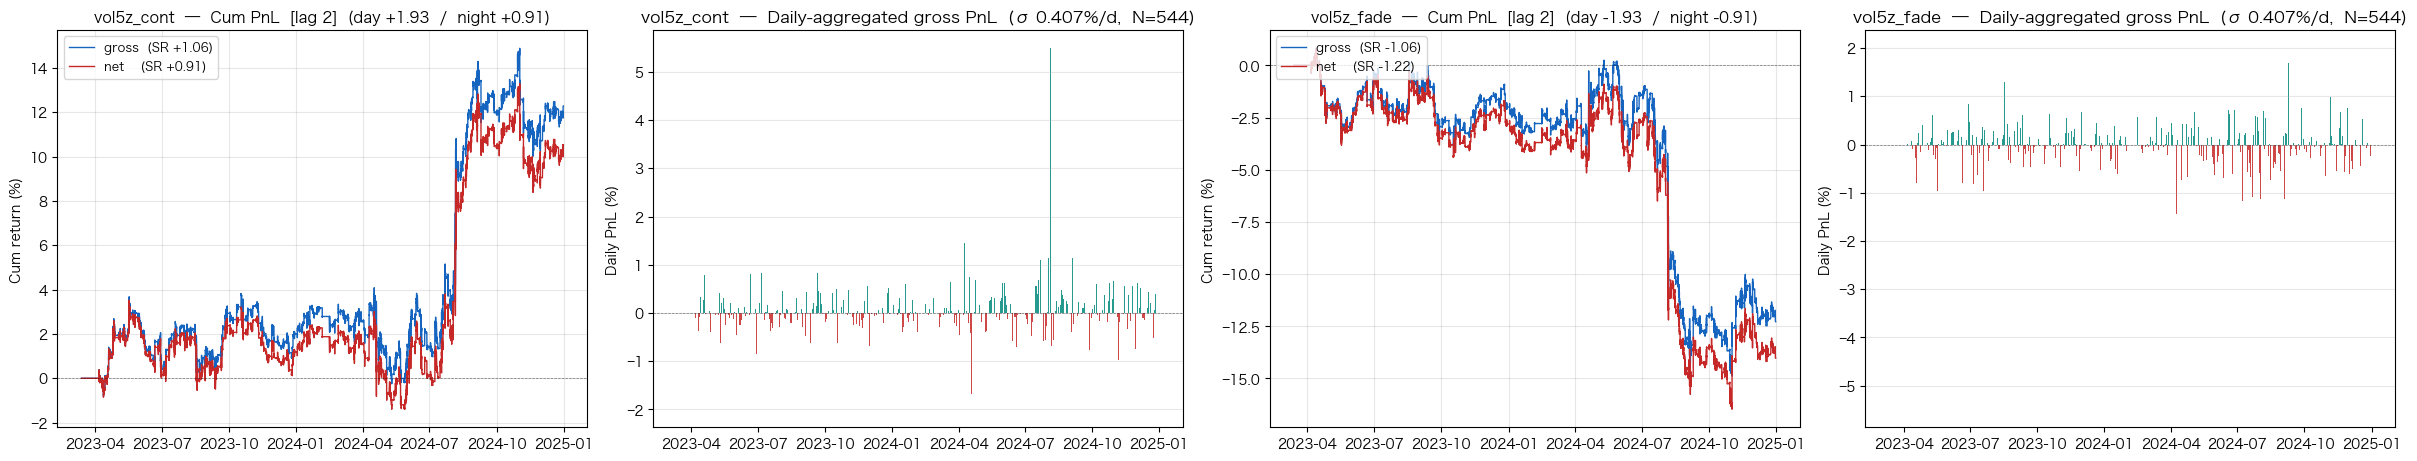

In [7]:
first5 = ASSET.between_time("08:46", "08:50")
vol5 = first5.groupby(first5.index.normalize())["volume"].sum()
vol5_z = ((vol5 - vol5.rolling(20, min_periods=5).mean().shift(1))
          / vol5.rolling(20, min_periods=5).std().shift(1)).dropna()

sign5 = np.sign(ret_open5).reindex(vol5_z.index)
vz_dir = (vol5_z * sign5).dropna()
vz_dir_n = tanh_norm(vz_dir, win=60)

vol_signals = {
    "vol5z_cont":  build_tod_signal( vz_dir_n, "08:50", "13:45"),
    "vol5z_fade":  build_tod_signal(-vz_dir_n, "08:50", "13:45"),
}
display(summarize(vol_signals))

cta.SimulateAllIntraday(
    *vol_signals.values(),
    names=list(vol_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 6. Last 30-min day-close return — carry to NEXT day

The hypothesis: institutions push positions into the close, and that flow persists overnight. Compute `close@13:45 / close@13:15 − 1` on day D, then emit it at 08:46 of day D+1 and hold for that whole day session. The asymmetry vs section 3: this captures direction of *late-session order flow*, not the overnight gap itself.

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
close30_fade,0.515,0.390,1.0,1.065,5.541,4.202,19.195,0.001
close30_cont,-0.515,-0.639,-1.0,-1.065,-5.541,-6.881,19.195,0.001


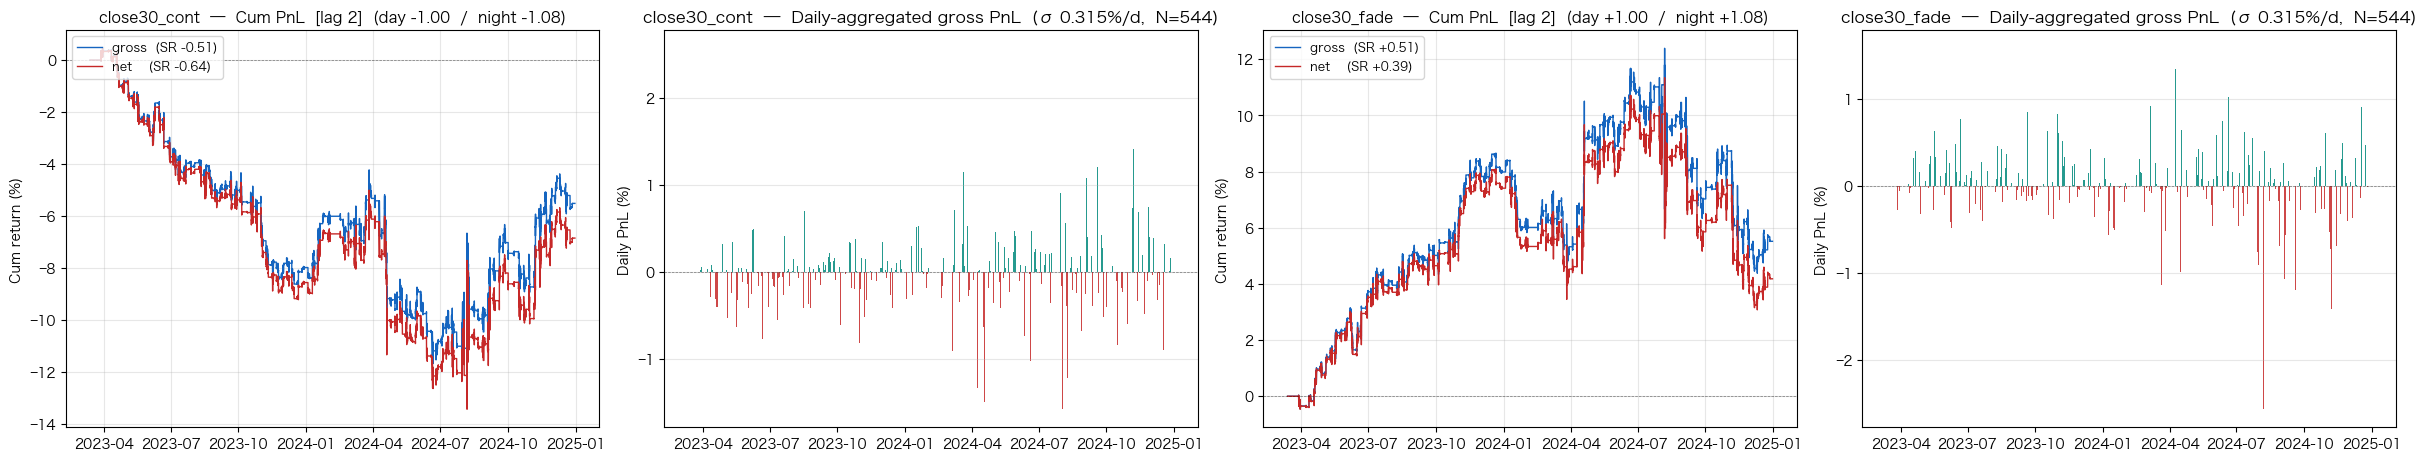

In [8]:
ret_close30 = (at_time(C, "13:45") / at_time(C, "13:15") - 1.0).dropna()
ret_close30_n = tanh_norm(ret_close30, win=60)
# shift by one date so it becomes a tomorrow-keyed feature
ret_close30_next = ret_close30_n.copy()
ret_close30_next.index = ret_close30_next.index + pd.Timedelta(days=1)

close_signals = {
    "close30_cont":  build_tod_signal( ret_close30_next, "08:46", "13:45"),
    "close30_fade":  build_tod_signal(-ret_close30_next, "08:46", "13:45"),
}
display(summarize(close_signals))

cta.SimulateAllIntraday(
    *close_signals.values(),
    names=list(close_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 7. Combined sweep — all time-of-day signals together

Bring every variant into one table sorted by net Sharpe. The headline question: do any of the "hold one decision per day" signals clear the buy-and-hold baseline (cum +27%, SR +0.97 from `intraday_signals.ipynb` section 0) with meaningfully less risk?

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
vol5z_cont,1.058,0.906,1.914,0.918,12.227,10.476,24.292,0.001
open30_cont,0.821,0.654,1.379,1.161,9.296,7.402,23.102,0.001
rng30_cont,0.807,0.624,1.369,1.199,10.598,8.197,23.102,0.001
close30_fade,0.515,0.390,1.000,1.065,5.541,4.202,19.195,0.001
open5_cont,0.292,0.148,0.416,0.878,3.842,1.947,24.880,0.001
open5_fade,-0.292,-0.435,-0.416,-0.878,-3.842,-5.738,24.880,0.001
close30_cont,-0.515,-0.639,-1.000,-1.065,-5.541,-6.881,19.195,0.001
open30_fade,-0.821,-0.988,-1.379,-1.161,-9.296,-11.189,23.102,0.001
rng30_fade,-0.807,-0.990,-1.369,-1.199,-10.598,-12.999,23.102,0.001
vol5z_fade,-1.058,-1.209,-1.914,-0.918,-12.227,-13.979,24.292,0.001


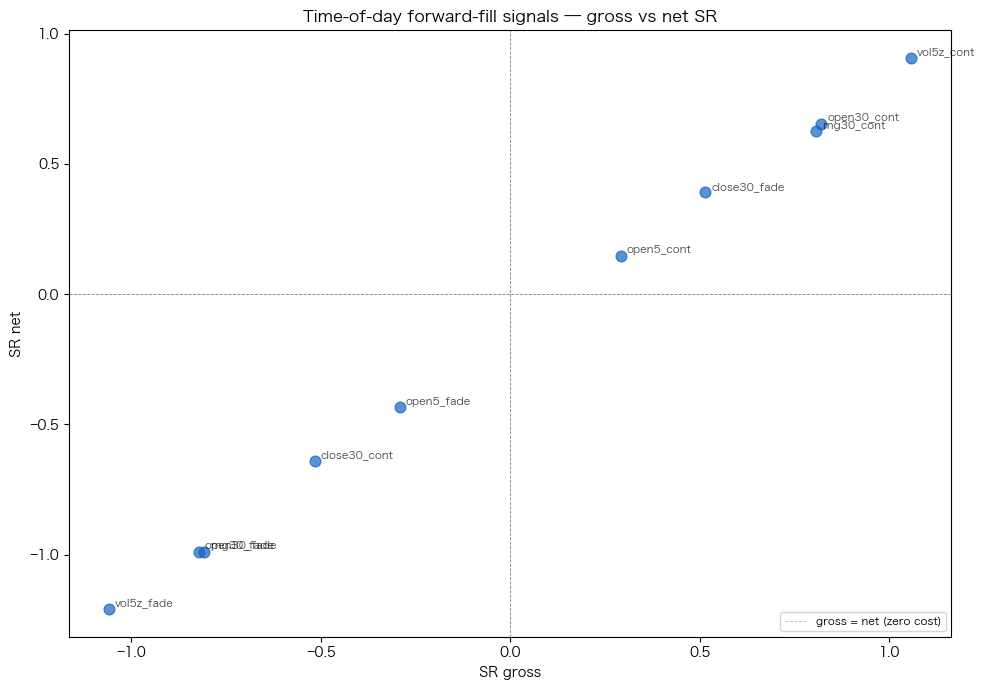

In [9]:
all_signals = {
    **open5_signals,
    **open30_signals,
    **gap_signals,
    **rng_signals,
    **vol_signals,
    **close_signals,
}
tbl = summarize(all_signals)
display(tbl)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(tbl["SR_gross"], tbl["SR_net"], s=60, alpha=0.7, color="#1565c0")
for name, row in tbl.iterrows():
    ax.annotate(name, (row["SR_gross"], row["SR_net"]),
                fontsize=8, alpha=0.7, xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="black", lw=0.6, ls="--", alpha=0.5)
ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
lim = max(abs(tbl[["SR_gross","SR_net"]].values).max(), 1.0)
ax.plot([-lim, lim], [-lim, lim], color="grey", lw=0.6, ls="--", alpha=0.5,
        label="gross = net (zero cost)")
ax.set_xlabel("SR gross"); ax.set_ylabel("SR net")
ax.set_title("Time-of-day forward-fill signals — gross vs net SR")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Dashboard for the top signal

Whatever the table picks as the winning net-SR variant, run it through the full 9-panel `SimulateIntraday` so day vs night breakdown, drawdown, and turnover are visible.

Top by SR_net: vol5z_cont


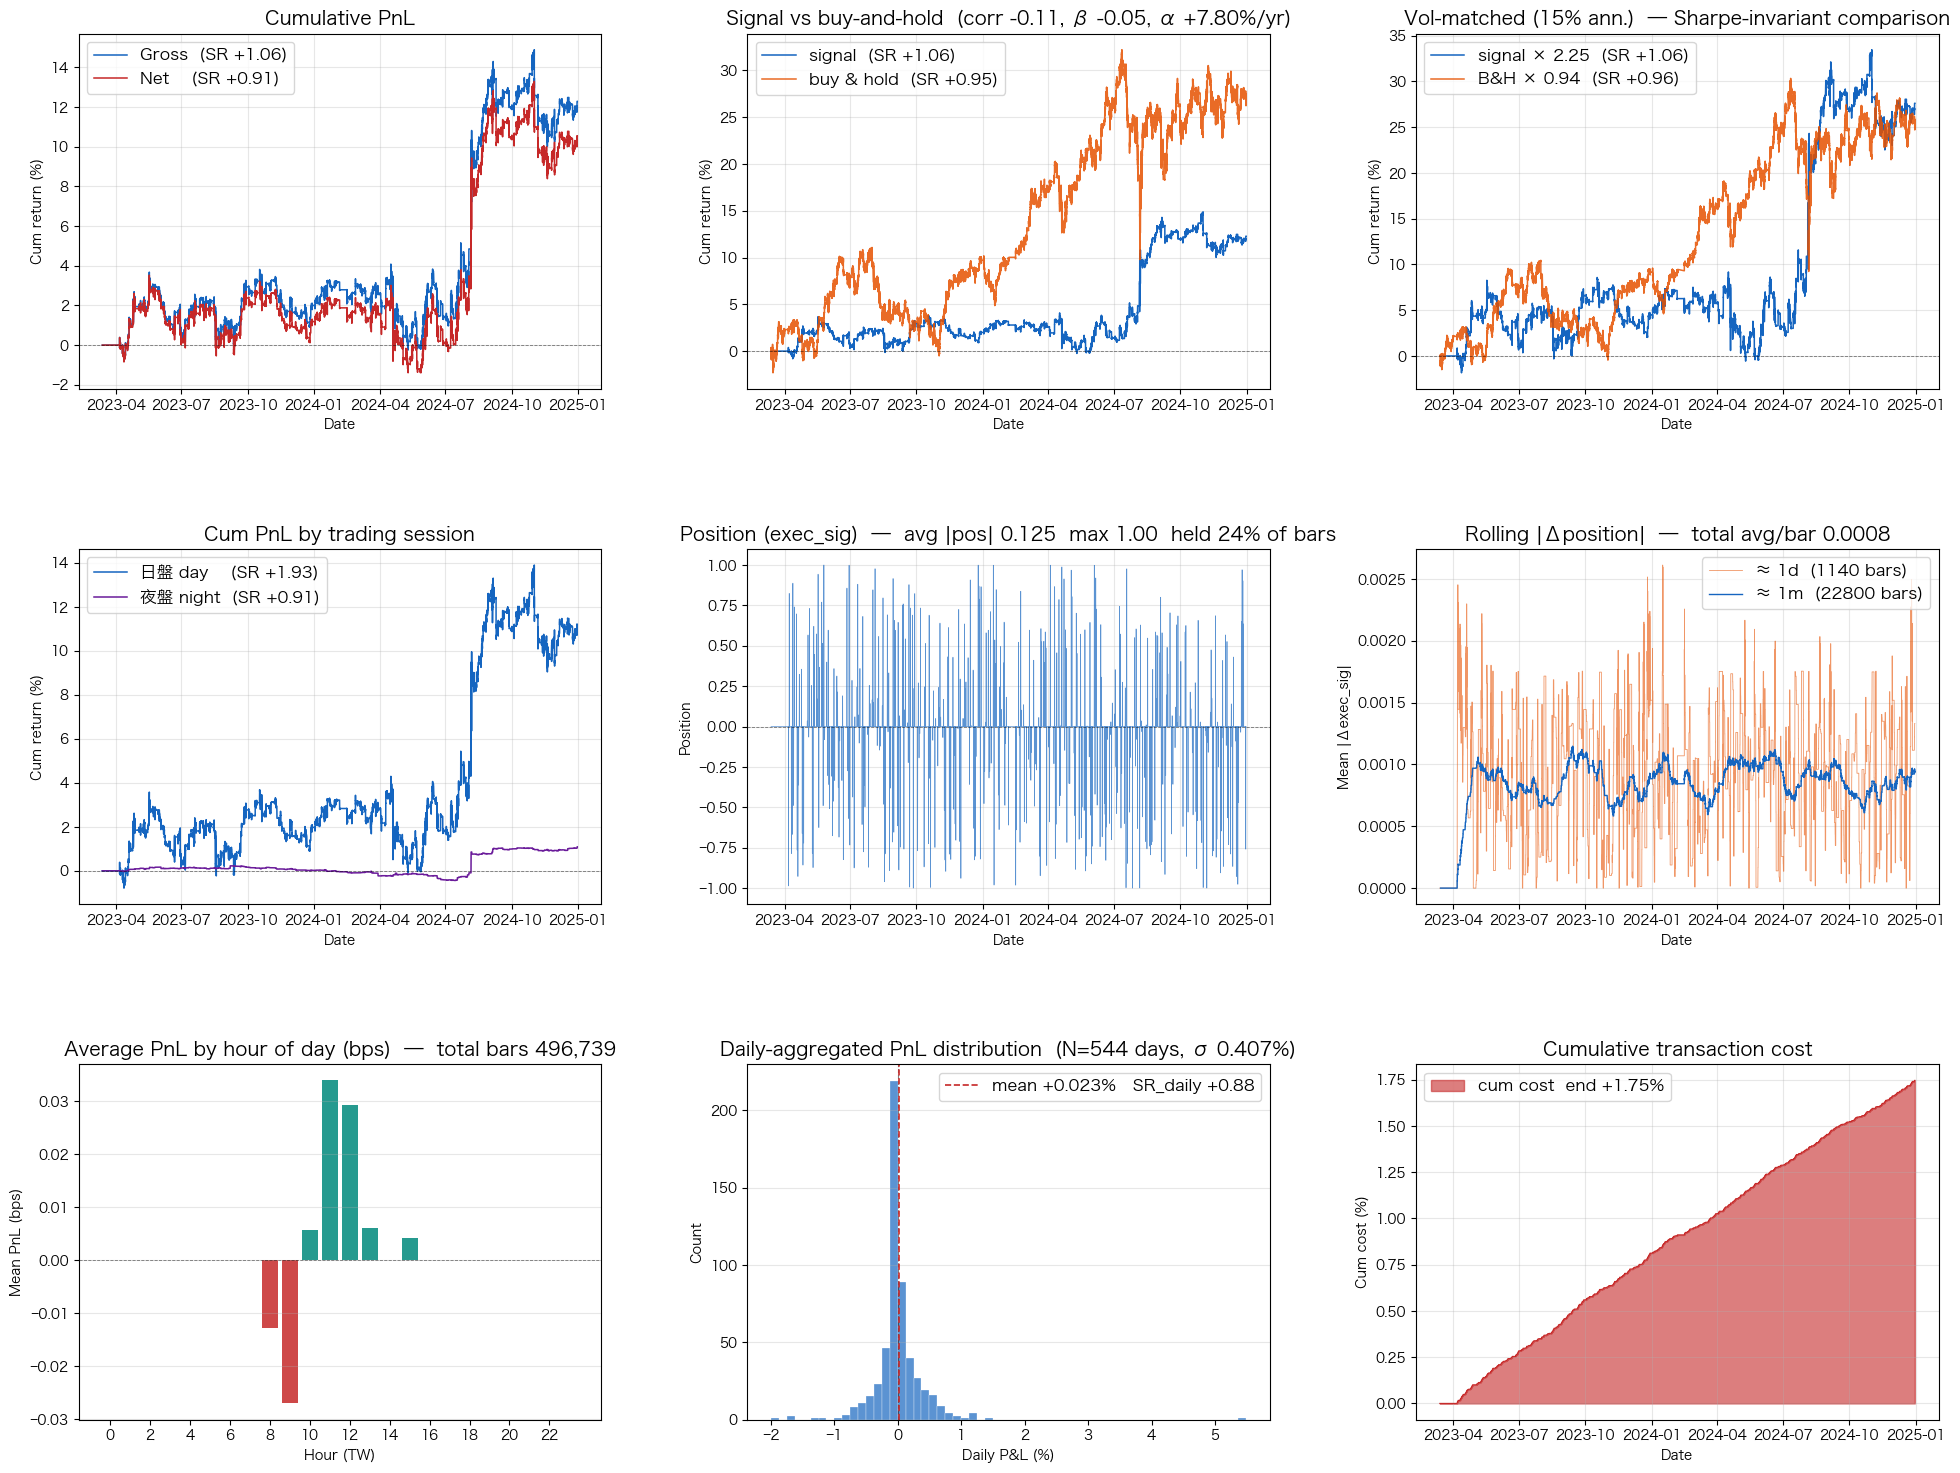

{'asset_obj': BaseAsset  MTX
   time_granularity : 1m
   bars             : 502,049
   start            : 2023-03-13
   end              : 2024-12-31
 
                         open     high      low    close  volume
 ts                                                             
 2023-03-13 08:46:00  15457.0  15488.0  15446.0  15479.0    5537
 2023-03-13 08:47:00  15478.0  15497.0  15478.0  15496.0    1808
 2023-03-13 08:48:00  15496.0  15515.0  15494.0  15508.0    2216
 2023-03-13 08:49:00  15509.0  15510.0  15493.0  15497.0    1266
 2023-03-13 08:50:00  15497.0  15506.0  15494.0  15506.0     959
 ...                      ...      ...      ...      ...     ...
 2024-12-30 23:56:00  22965.0  22978.0  22964.0  22978.0     187
 2024-12-30 23:57:00  22977.0  22986.0  22976.0  22981.0     270
 2024-12-30 23:58:00  22981.0  22984.0  22975.0  22976.0     145
 2024-12-30 23:59:00  22977.0  22986.0  22975.0  22982.0     120
 2024-12-31 00:00:00  22982.0  22995.0  22982.0  22994.0     367
 
 

In [10]:
best_name = tbl.index[0]
best_sig  = all_signals[best_name]
print(f"Top by SR_net: {best_name}")
cta.SimulateIntraday(best_sig, time_granularity="1m", normalize=False)